In [1]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
   for gpu in gpus:
       tf.config.experimental.set_memory_growth(gpu, True)

print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [13]:
# import system libs
import os
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

print ('modules loaded')

modules loaded


In [19]:
# ── 0. Download dataset from kaggle ──────────────────────────────────────────────────────────────────
import kagglehub
from kagglehub import KaggleDatasetAdapter
import kaggle

! kaggle datasets download -d uraninjo/augmented-alzheimer-mri-dataset -p /Users/Ahmad/UNI-work/year3/FYP/Project/alzheimers/datasets

Dataset URL: https://www.kaggle.com/datasets/uraninjo/augmented-alzheimer-mri-dataset
License(s): GNU Lesser General Public License 3.0
100%|████████████████████████████████████████| 380M/380M [00:43<00:00, 3.87MB/s]
100%|████████████████████████████████████████| 380M/380M [00:43<00:00, 9.23MB/s]


In [20]:
import zipfile 
zf = '/Users/Ahmad/UNI-work/year3/FYP/Project/alzheimers/datasets/augmented-alzheimer-mri-dataset.zip'
target_dir = "/Users/Ahmad/UNI-work/year3/FYP/Project/alzheimers/datasets"
zfile = zipfile.ZipFile(zf)
zfile.extractall(target_dir)

In [11]:
import sklearn.metrics as metrics
from keras.callbacks import LearningRateScheduler
from keras.preprocessing.image import ImageDataGenerator
annealer = LearningRateScheduler(lambda x: 1e-3 * 0.95 ** x, verbose=0)

In [4]:
import os
import pandas as pd

MildDemented_dir = '/Users/Ahmad/UNI-work/year3/FYP/Project/alzheimers/datasets/AugmentedAlzheimerDataset/MildDemented'
ModerateDemented_dir = '/Users/Ahmad/UNI-work/year3/FYP/Project/alzheimers/datasets/AugmentedAlzheimerDataset/ModerateDemented'
NonDemented_dir = '/Users/Ahmad/UNI-work/year3/FYP/Project/alzheimers/datasets/AugmentedAlzheimerDataset/NonDemented'
VeryMildDemented_dir = '/Users/Ahmad/UNI-work/year3/FYP/Project/alzheimers/datasets/AugmentedAlzheimerDataset/VeryMildDemented'

filepaths = []
labels = []
dict_list = [MildDemented_dir, ModerateDemented_dir, NonDemented_dir, VeryMildDemented_dir]
class_labels = ['Mild Demented', 'Moderate Demented', 'Non Demented', 'Very MildDemented']

for i, j in enumerate(dict_list):
    flist = os.listdir(j)
    for f in flist:
        fpath = os.path.join(j, f)
        filepaths.append(fpath)
        labels.append(class_labels[i])

Fseries = pd.Series(filepaths, name="filepaths")
Lseries = pd.Series(labels, name="labels")
Alzheimer_data = pd.concat([Fseries, Lseries], axis=1)
Alzheimer_df = pd.DataFrame(Alzheimer_data)
print(Alzheimer_df.head())
print(Alzheimer_df["labels"].value_counts())

                                           filepaths         labels
0  /Users/Ahmad/UNI-work/year3/FYP/Project/alzhei...  Mild Demented
1  /Users/Ahmad/UNI-work/year3/FYP/Project/alzhei...  Mild Demented
2  /Users/Ahmad/UNI-work/year3/FYP/Project/alzhei...  Mild Demented
3  /Users/Ahmad/UNI-work/year3/FYP/Project/alzhei...  Mild Demented
4  /Users/Ahmad/UNI-work/year3/FYP/Project/alzhei...  Mild Demented
labels
Non Demented         9600
Mild Demented        8960
Very MildDemented    8960
Moderate Demented    6464
Name: count, dtype: int64


In [5]:
Alzheimer_df.shape

(33984, 2)

In [7]:
from sklearn.model_selection import train_test_split

train_images, test_images = train_test_split(Alzheimer_df, test_size=0.3, random_state=42)
train_set, val_set = train_test_split(Alzheimer_df, test_size=0.2, random_state=42)

In [26]:
print(train_set.shape)
print(test_images.shape)
print(val_set.shape)
print(train_images.shape)

(27187, 2)
(10196, 2)
(6797, 2)
(23788, 2)


In [14]:
image_gen = ImageDataGenerator(preprocessing_function= tf.keras.applications.mobilenet_v2.preprocess_input)
train = image_gen.flow_from_dataframe(dataframe= train_set,x_col="filepaths",y_col="labels",
                                      target_size=(244,244),
                                      color_mode='rgb',
                                      class_mode="categorical", #used for Sequential Model
                                      batch_size=32,
                                      shuffle=False            #do not shuffle data
                                     )
test = image_gen.flow_from_dataframe(dataframe= test_images,x_col="filepaths", y_col="labels",
                                     target_size=(244,244),
                                     color_mode='rgb',
                                     class_mode="categorical",
                                     batch_size=32,
                                     shuffle= False
                                    )
val = image_gen.flow_from_dataframe(dataframe= val_set,x_col="filepaths", y_col="labels",
                                    target_size=(244,244),
                                    color_mode= 'rgb',
                                    class_mode="categorical",
                                    batch_size=32,
                                    shuffle=False
                                   )

Found 27187 validated image filenames belonging to 4 classes.
Found 10196 validated image filenames belonging to 4 classes.
Found 6797 validated image filenames belonging to 4 classes.


In [28]:
classes=list(train.class_indices.keys())
print (classes)

['Mild Demented', 'Moderate Demented', 'Non Demented', 'Very MildDemented']


In [29]:
def show_knee_images(image_gen):
    test_dict = test.class_indices
    classes = list(test_dict.keys())
    images, labels=next(image_gen) # get a sample batch from the generator
    plt.figure(figsize=(20,20))
    length = len(labels)
    if length<25:
        r=length
    else:
        r=25
    for i in range(r):
        plt.subplot(5,5,i+1)
        image=(images[i]+1)/2 #scale images between 0 and 1
        plt.imshow(image)
        index=np.argmax(labels[i])
        class_name=classes[index]
        plt.title(class_name, color="green",fontsize=16)
        plt.axis('off')
    plt.show()

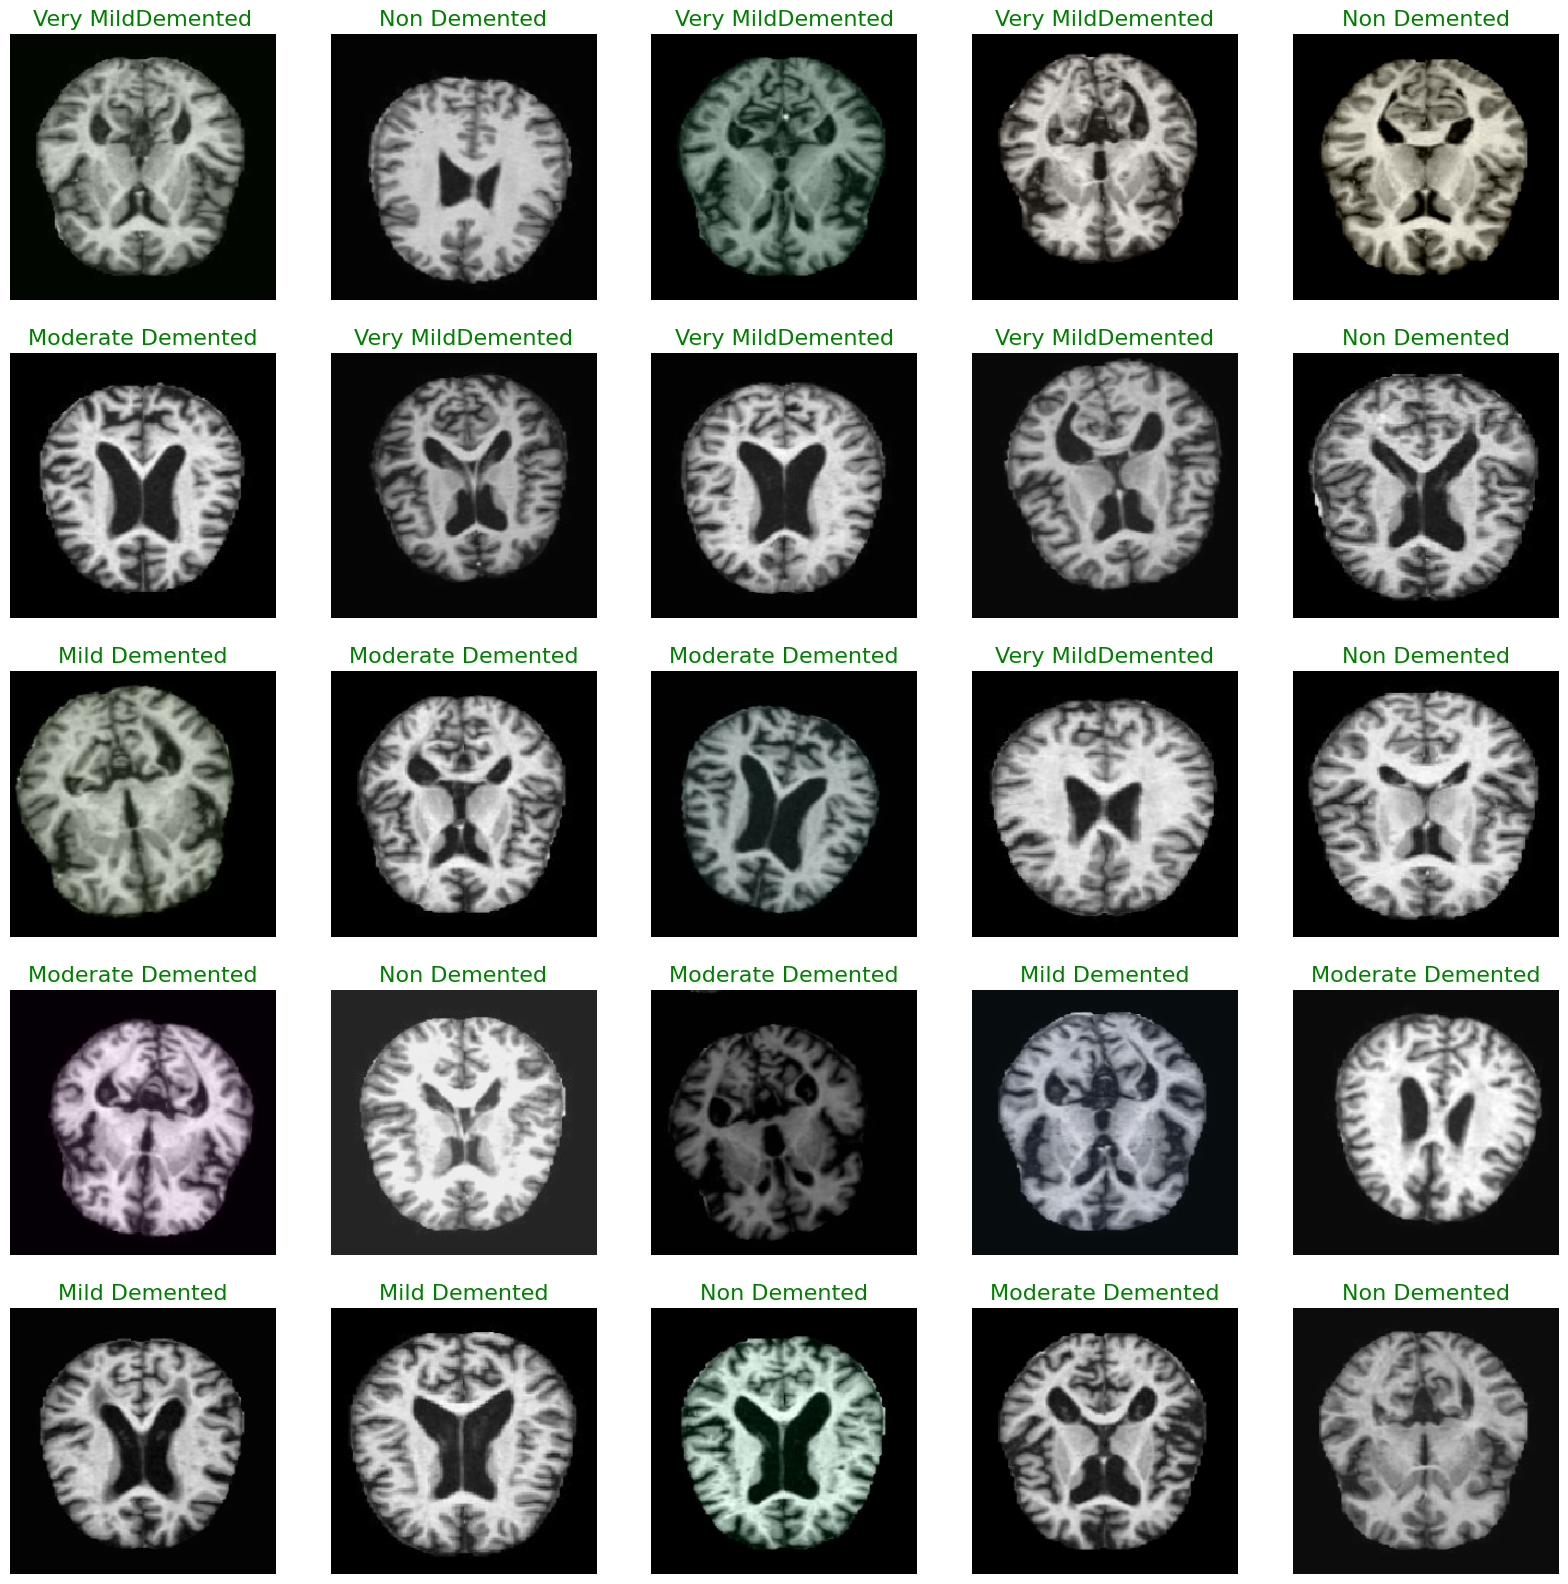

In [30]:
show_knee_images(train)


In [33]:
model = keras.models.Sequential([
    keras.layers.Conv2D(filters=128, kernel_size=(8, 8), strides=(3, 3), activation='relu', input_shape=(224, 224, 3)),
    keras.layers.BatchNormalization(),
    
    keras.layers.Conv2D(filters=256, kernel_size=(5, 5), strides=(1, 1), activation='relu', padding="same"),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPool2D(pool_size=(3, 3)),
    
    keras.layers.Conv2D(filters=256, kernel_size=(3, 3), strides=(1, 1), activation='relu', padding="same"),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(filters=256, kernel_size=(1, 1), strides=(1, 1), activation='relu', padding="same"),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(filters=256, kernel_size=(1, 1), strides=(1, 1), activation='relu', padding="same"),
    keras.layers.BatchNormalization(),
    
    keras.layers.Conv2D(filters=512, kernel_size=(3, 3), activation='relu', padding="same"),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPool2D(pool_size=(2, 2)),
    
    keras.layers.Conv2D(filters=512, kernel_size=(3, 3), activation='relu', padding="same"),
    keras.layers.BatchNormalization(),
    
    keras.layers.Conv2D(filters=512, kernel_size=(3, 3), activation='relu', padding="same"),
    keras.layers.BatchNormalization(),
    
    keras.layers.MaxPool2D(pool_size=(2, 2)),
    
    keras.layers.Conv2D(filters=512, kernel_size=(3, 3), activation='relu', padding="same"),
    keras.layers.BatchNormalization(),
    
    keras.layers.MaxPool2D(pool_size=(2, 2)),
    
    keras.layers.Flatten(),
    keras.layers.Dense(1024, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(1024, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(4, activation='softmax')
])

model.compile(
    loss='categorical_crossentropy',
    optimizer=tf.optimizers.SGD(learning_rate=0.001),
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_5 (Conv2D)           (None, 73, 73, 128)       24704     
                                                                 
 batch_normalization (Batch  (None, 73, 73, 128)       512       
 Normalization)                                                  
                                                                 
 conv2d_6 (Conv2D)           (None, 73, 73, 256)       819456    
                                                                 
 batch_normalization_1 (Bat  (None, 73, 73, 256)       1024      
 chNormalization)                                                
                                                                 
 max_pooling2d_5 (MaxPoolin  (None, 24, 24, 256)       0         
 g2D)                                                            
                                                      

In [34]:
history = model.fit(train, epochs=22, validation_data=val, validation_freq=1)

Epoch 1/22


2026-03-04 11:43:14.161296: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node SGD/AssignVariableOp.


850/850 [==============================] - 891s 1s/step - loss: 3.2712 - accuracy: 0.3563 - val_loss: 1.0080 - val_accuracy: 0.5336
Epoch 2/22
850/850 [==============================] - 993s 1s/step - loss: 1.4520 - accuracy: 0.4810 - val_loss: 0.8083 - val_accuracy: 0.6178
Epoch 3/22
850/850 [==============================] - 1005s 1s/step - loss: 1.0027 - accuracy: 0.5509 - val_loss: 0.7709 - val_accuracy: 0.6194
Epoch 4/22
850/850 [==============================] - 976s 1s/step - loss: 0.8908 - accuracy: 0.5876 - val_loss: 0.7761 - val_accuracy: 0.6259
Epoch 5/22
850/850 [==============================] - 1025s 1s/step - loss: 0.8424 - accuracy: 0.6095 - val_loss: 0.7119 - val_accuracy: 0.6594
Epoch 6/22
850/850 [==============================] - 971s 1s/step - loss: 0.7930 - accuracy: 0.6311 - val_loss: 0.6734 - val_accuracy: 0.6802
Epoch 7/22
850/850 [==============================] - 899s 1s/step - loss: 0.7535 - accuracy: 0.6537 - val_loss: 0.6663 - val_accuracy: 0.6831
Epoch 8/

In [35]:
model.evaluate(test, verbose=1)

319/319 [==============================] - 70s 219ms/step - loss: 0.4264 - accuracy: 0.8787


[0.4263963997364044, 0.8786779046058655]

In [36]:
model.save(filepath="/Users/Ahmad/UNI-work/year3/FYP/Project/alzheimers/models/trained/alzheimers.keras")

In [37]:
pred = model.predict(test)
pred = np.argmax(pred, axis=1) #pick class with highest  probability

labels = (train.class_indices)
labels = dict((v,k) for k,v in labels.items())
pred2 = [labels[k] for k in pred]

319/319 [==============================] - 70s 219ms/step


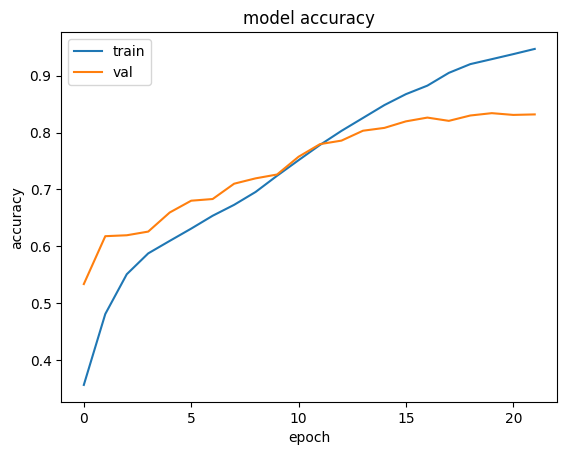

In [38]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

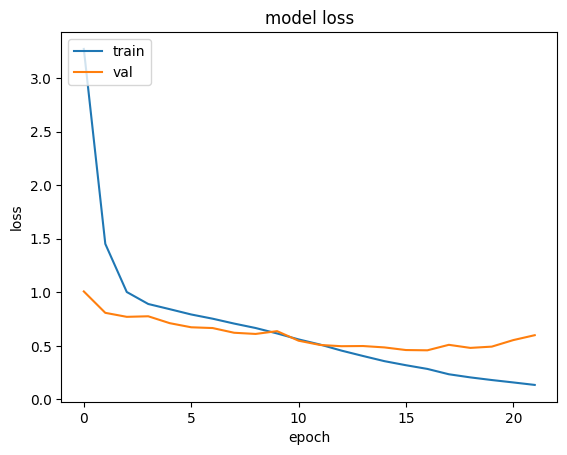

In [39]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [40]:
from sklearn.metrics import confusion_matrix, accuracy_score

y_test = test_images.labels # set y_test to the expected output
print(classification_report(y_test, pred2))
print("Accuracy of the Model:","{:.1f}%".format(accuracy_score(y_test, pred2)*100))

                   precision    recall  f1-score   support

    Mild Demented       0.82      0.94      0.88      2693
Moderate Demented       0.99      0.99      0.99      1977
     Non Demented       0.91      0.84      0.87      2811
Very MildDemented       0.83      0.77      0.80      2715

         accuracy                           0.88     10196
        macro avg       0.89      0.89      0.89     10196
     weighted avg       0.88      0.88      0.88     10196

Accuracy of the Model: 87.9%


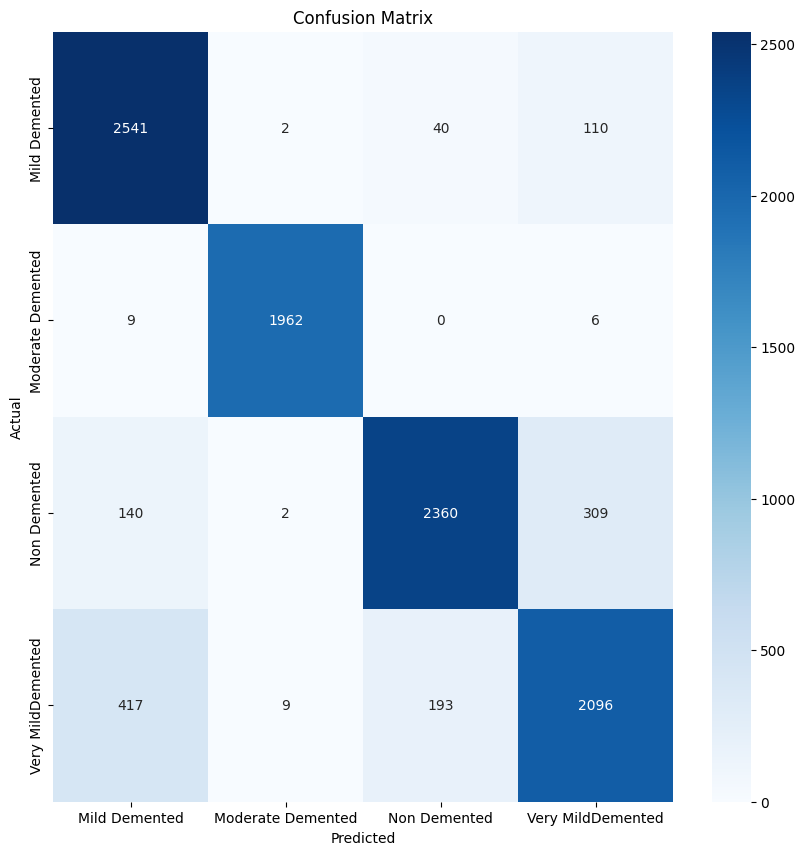

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Define the class labels
class_labels = ['Mild Demented', 'Moderate Demented', 'Non Demented', 'Very MildDemented']

# Calculate the confusion matrix
cm = confusion_matrix(y_test, pred2)

# Create a figure and plot the confusion matrix as a heatmap
plt.figure(figsize=(10, 10))
sns.heatmap(cm, annot=True, fmt='g', vmin=0, cmap='Blues')

# Set tick labels and axis labels
plt.xticks(ticks=[0.5, 1.5, 2.5, 3.5], labels=class_labels)
plt.yticks(ticks=[0.5, 1.5, 2.5, 3.5], labels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")

# Set the title
plt.title("Confusion Matrix")

# Show the plot
plt.show()

In [1]:
from keras.models import load_model
model = load_model('models/trained/alzheimers.keras')

2026-03-11 17:44:02.261302: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-03-11 17:44:02.261328: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-03-11 17:44:02.261331: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-03-11 17:44:02.261372: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-11 17:44:02.261399: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [15]:
from sklearn.metrics import roc_auc_score

y_test = test_images.labels 

y_probs = model.predict(test)
auc_score = roc_auc_score(y_test, y_probs, multi_class='ovr', average='macro')

print(f"Multiclass ROC AUC Score (One-vs-Rest): {auc_score:.4f}")

  1/319 [..............................] - ETA: 47s

2026-03-11 17:49:52.230397: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


319/319 [==============================] - 66s 206ms/step
Multiclass ROC AUC Score (One-vs-Rest): 0.9783
